# Bangla Audio Deepfake Detection
## WavLM-Large + Modified AASIST + OC-Softmax + RawBoost

This notebook implements a complete pipeline for detecting deepfake Bangla audio:

| Component | Detail |
|---|---|
| **Frontend** | WavLM-Large (fine-tuned top 12 layers) |
| **Backend** | Modified AASIST with graph attention |
| **Loss** | One-Class Softmax (OC-Softmax) |
| **Augmentation** | RawBoost (noise, reverb, compression, pitch, stretch) |

---

In [1]:
import os, re, glob, random, warnings, json, math
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
from scipy.signal import fftconvolve, butter, sosfilt
from scipy.stats import norm as scipy_norm
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from transformers import WavLMModel

warnings.filterwarnings('ignore')
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.8.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4090


In [2]:
# ======================== Configuration ========================

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data
BASE_DIR = "./final_data"
DATASETS = {
    "mozilla": {
        "real": os.path.join(BASE_DIR, "deepfake_data_mozilla", "real_wav"),
        "fake": os.path.join(BASE_DIR, "deepfake_data_mozilla", "deepfake_wav"),
    },
    "sust": {
        "real": os.path.join(BASE_DIR, "deepfake_data_sust", "real_wav"),
        "fake": os.path.join(BASE_DIR, "deepfake_data_sust", "deepfake_wav"),
    },
    "news": {
        "real": os.path.join(BASE_DIR, "deepfake_data_news", "real_wav"),
    },
}
SAMPLE_RATE = 16000
AUDIO_DURATION = 5
MAX_AUDIO_LEN = SAMPLE_RATE * AUDIO_DURATION

# Model
WAVLM_MODEL_NAME = "microsoft/wavlm-large"
WAVLM_DIM = 1024
WAVLM_FREEZE_LAYERS = 12
AASIST_HIDDEN = 160
AASIST_EMB_DIM = 128
AASIST_NUM_HEADS = 4
AASIST_NUM_GAT_LAYERS = 2
NUM_SPECTRAL_NODES = 32
DROPOUT = 0.3

# OC-Softmax
OC_MARGIN = 0.5
OC_SCALE = 10.0

# Training
BATCH_SIZE = 4
ACCUMULATION_STEPS = 4
NUM_EPOCHS = 50
LR_WAVLM = 1e-5
LR_AASIST = 1e-4
WEIGHT_DECAY = 0.01
GRAD_CLIP = 1.0
PATIENCE = 7
NUM_WORKERS = 0

# Split
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Device: {DEVICE}")
print(f"Effective batch size: {BATCH_SIZE * ACCUMULATION_STEPS}")

Device: cuda
Effective batch size: 16


---
## Step 2 — Data Pipeline

Load audio paths, extract speaker IDs for speaker-independent splitting, and visualize the dataset.

In [3]:
def extract_speaker_id(filepath, source):
    fname = os.path.splitext(os.path.basename(filepath))[0]
    if source == "mozilla":
        m = re.match(r'common_voice_(s\d+)_', fname)
        return f"mozilla_{m.group(1)}" if m else "mozilla_unk"
    elif source == "sust":
        return f"sust_{fname[:2]}"
    elif source == "news":
        idx = int(fname)
        return f"news_{idx // 100}"
    return "unknown"


def build_dataset_df(datasets_dict):
    records = []
    for source, paths in datasets_dict.items():
        for label_name, folder in paths.items():
            label = 0 if label_name == "real" else 1
            wav_files = sorted(glob.glob(os.path.join(folder, "*.wav")))
            for fp in wav_files:
                records.append({
                    "filepath": fp,
                    "label": label,
                    "label_name": label_name.capitalize(),
                    "source": source,
                    "speaker_id": extract_speaker_id(fp, source),
                })
    return pd.DataFrame(records)


df = build_dataset_df(DATASETS)
print(f"Total samples: {len(df)}")
print(f"\nClass distribution:\n{df['label_name'].value_counts()}")
print(f"\nSamples per source:")
print(df.groupby(['source', 'label_name']).size().unstack(fill_value=0))
print(f"\nUnique speakers: {df['speaker_id'].nunique()}")
for src in sorted(df['source'].unique()):
    n = df[df['source'] == src]['speaker_id'].nunique()
    print(f"  {src}: {n} speakers")

Total samples: 26592

Class distribution:
label_name
Real    13796
Fake    12796
Name: count, dtype: int64

Samples per source:
label_name  Fake  Real
source                
mozilla     2797  2797
news           0  1000
sust        9999  9999

Unique speakers: 85
  mozilla: 5 speakers
  news: 10 speakers
  sust: 70 speakers


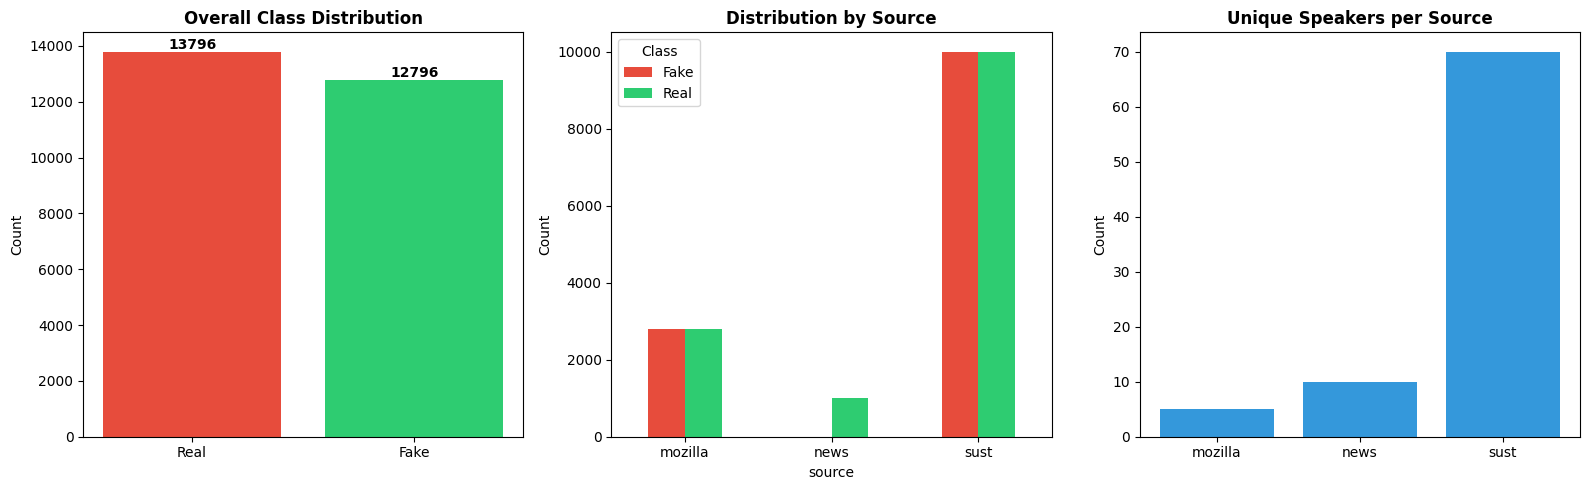

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

counts = df['label_name'].value_counts()
bars = axes[0].bar(counts.index, counts.values, color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Overall Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for b in bars:
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 80,
                 str(int(b.get_height())), ha='center', fontweight='bold')

src_counts = df.groupby(['source', 'label_name']).size().unstack(fill_value=0)
src_counts.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'])
axes[1].set_title('Distribution by Source', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Class')

speaker_counts = df.groupby('source')['speaker_id'].nunique()
axes[2].bar(speaker_counts.index, speaker_counts.values, color='#3498db')
axes[2].set_title('Unique Speakers per Source', fontweight='bold')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
def speaker_independent_split(df, train_ratio=0.70, val_ratio=0.15, seed=42):
    rng = np.random.default_rng(seed)
    speaker_info = df.groupby('speaker_id').agg(
        count=('label', 'size'),
        n_real=('label', lambda x: (x == 0).sum()),
        n_fake=('label', lambda x: (x == 1).sum()),
    ).reset_index()

    speakers = speaker_info['speaker_id'].values.copy()
    rng.shuffle(speakers)

    total = len(df)
    target_train = int(total * train_ratio)
    target_val = int(total * val_ratio)

    train_spk, val_spk, test_spk = [], [], []
    cum_train, cum_val = 0, 0

    for spk in speakers:
        n = int(speaker_info[speaker_info['speaker_id'] == spk]['count'].values[0])
        if cum_train < target_train:
            train_spk.append(spk)
            cum_train += n
        elif cum_val < target_val:
            val_spk.append(spk)
            cum_val += n
        else:
            test_spk.append(spk)

    return (
        df[df['speaker_id'].isin(train_spk)].reset_index(drop=True),
        df[df['speaker_id'].isin(val_spk)].reset_index(drop=True),
        df[df['speaker_id'].isin(test_spk)].reset_index(drop=True),
    )

train_df, val_df, test_df = speaker_independent_split(df, TRAIN_RATIO, VAL_RATIO, SEED)

for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    nr = (split['label'] == 0).sum()
    nf = (split['label'] == 1).sum()
    ns = split['speaker_id'].nunique()
    print(f"{name:5s}: {len(split):6d} samples | {nr:5d} real, {nf:5d} fake | {ns} speakers")

assert set(train_df['speaker_id']) & set(val_df['speaker_id']) == set()
assert set(train_df['speaker_id']) & set(test_df['speaker_id']) == set()
assert set(val_df['speaker_id']) & set(test_df['speaker_id']) == set()
print("\nNo speaker overlap between splits.")

Train:  19237 samples | 10019 real,  9218 fake | 47 speakers
Val  :   5461 samples |  2580 real,  2881 fake | 25 speakers
Test :   1894 samples |  1197 real,   697 fake | 13 speakers

No speaker overlap between splits.


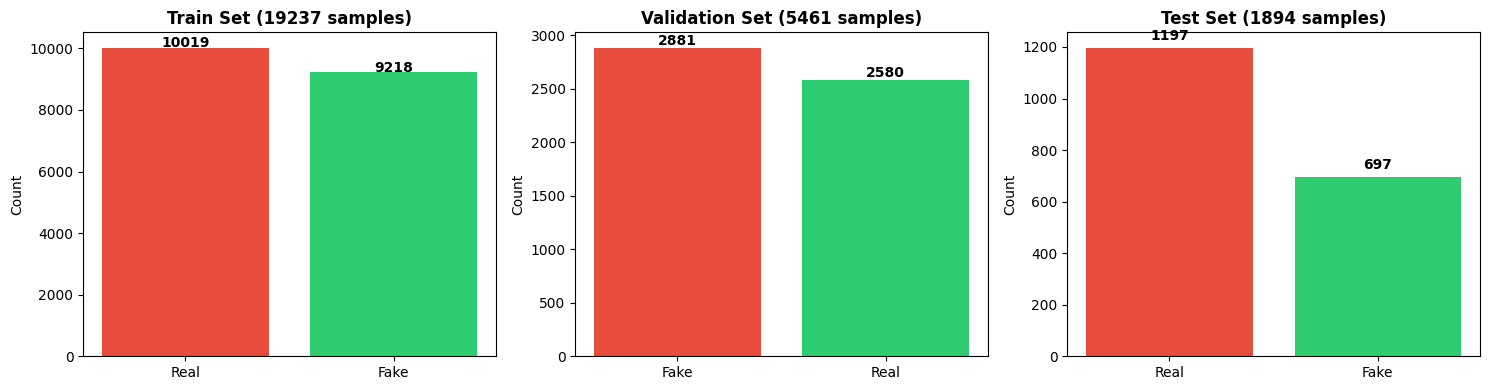

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (split_df, name) in zip(axes, [(train_df, 'Train'), (val_df, 'Validation'), (test_df, 'Test')]):
    vc = split_df['label_name'].value_counts()
    bars = ax.bar(vc.index, vc.values, color=['#e74c3c', '#2ecc71'])
    ax.set_title(f'{name} Set ({len(split_df)} samples)', fontweight='bold')
    ax.set_ylabel('Count')
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 30,
                str(int(b.get_height())), ha='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 2b — RawBoost Data Augmentation

Implements seven augmentation types applied randomly during training:
1. Random gain scaling
2. Additive Gaussian noise (SNR 5-30 dB)
3. Random clipping
4. Reverberation (synthetic RIR convolution)
5. MP3 compression simulation
6. Pitch shift (+-1 semitone)
7. Time stretch (0.9-1.1)

In [7]:
class RawBoost:
    def __init__(self, sr=16000, p=0.6):
        self.sr = sr
        self.p = p

    def __call__(self, audio):
        aug_fns = [
            self.gain_scaling,
            self.additive_noise,
            self.random_clipping,
            self.reverberation,
            self.mp3_compression_sim,
            self.pitch_shift,
            self.time_stretch,
        ]
        n_augs = random.randint(1, 3)
        chosen = random.sample(aug_fns, min(n_augs, len(aug_fns)))
        for fn in chosen:
            if random.random() < self.p:
                audio = fn(audio)
        return np.clip(audio, -1.0, 1.0).astype(np.float32)

    def gain_scaling(self, audio):
        gain = 10 ** (random.uniform(-6, 6) / 20)
        return audio * gain

    def additive_noise(self, audio):
        snr_db = random.uniform(5, 30)
        sig_power = np.mean(audio ** 2) + 1e-10
        noise_power = sig_power / (10 ** (snr_db / 10))
        return audio + np.random.randn(len(audio)).astype(np.float32) * np.sqrt(noise_power)

    def random_clipping(self, audio):
        thresh = np.max(np.abs(audio)) * random.uniform(0.5, 0.9)
        return np.clip(audio, -thresh, thresh)

    def reverberation(self, audio):
        rt60 = random.uniform(0.2, 0.8)
        n = int(self.sr * rt60)
        t = np.arange(n, dtype=np.float32) / self.sr
        rir = np.random.randn(n).astype(np.float32) * np.exp(-6.9 * t / rt60)
        rir[0] = 1.0
        rir /= np.abs(rir).max() + 1e-8
        rev = fftconvolve(audio, rir, mode='full')[:len(audio)].astype(np.float32)
        mix = random.uniform(0.3, 0.7)
        return (1 - mix) * audio + mix * rev

    def mp3_compression_sim(self, audio):
        cutoff = random.uniform(4000, 8000)
        sos = butter(5, cutoff / (self.sr / 2), btype='low', output='sos')
        filtered = sosfilt(sos, audio).astype(np.float32)
        bits = random.choice([8, 10, 12])
        scale = 2 ** (bits - 1)
        return np.round(filtered * scale).astype(np.float32) / scale

    def pitch_shift(self, audio):
        n_steps = random.uniform(-1, 1)
        return librosa.effects.pitch_shift(audio, sr=self.sr, n_steps=n_steps)

    def time_stretch(self, audio):
        rate = random.uniform(0.9, 1.1)
        stretched = librosa.effects.time_stretch(audio, rate=rate)
        if len(stretched) >= len(audio):
            return stretched[:len(audio)]
        return np.pad(stretched, (0, len(audio) - len(stretched)))

print("RawBoost augmentation ready.")

RawBoost augmentation ready.


---
## Step 3 — Audio Dataset & DataLoaders

On-the-fly audio loading with optional RawBoost augmentation.
Audio is loaded at 16 kHz, padded/truncated to 5 seconds, and normalized.

In [8]:
class BanglaAudioDataset(Dataset):
    def __init__(self, dataframe, sr=SAMPLE_RATE, duration=AUDIO_DURATION, augment=False):
        self.df = dataframe.reset_index(drop=True)
        self.sr = sr
        self.max_len = sr * duration
        self.augment = augment
        self.rawboost = RawBoost(sr=sr) if augment else None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        audio, _ = librosa.load(row['filepath'], sr=self.sr, duration=self.max_len / self.sr)

        if len(audio) < self.max_len:
            audio = np.pad(audio, (0, self.max_len - len(audio)))
        else:
            audio = audio[:self.max_len]

        if self.augment and self.rawboost is not None:
            audio = self.rawboost(audio)

        audio = (audio - audio.mean()) / (audio.std() + 1e-7)
        return torch.from_numpy(audio.astype(np.float32)), torch.tensor(row['label'], dtype=torch.long)


train_ds = BanglaAudioDataset(train_df, augment=True)
val_ds   = BanglaAudioDataset(val_df,   augment=False)
test_ds  = BanglaAudioDataset(test_df,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train: {len(train_ds)} samples, {len(train_loader)} batches")
print(f"Val:   {len(val_ds)} samples, {len(val_loader)} batches")
print(f"Test:  {len(test_ds)} samples, {len(test_loader)} batches")

Train: 19237 samples, 4809 batches
Val:   5461 samples, 1366 batches
Test:  1894 samples, 474 batches


---
## Step 3-5 — Model Architecture

### WavLM Frontend
- Pretrained `microsoft/wavlm-large` (24 transformer layers, 1024-dim)
- Freeze feature extractor + first 12 transformer layers
- Fine-tune remaining 12 layers

### Modified AASIST Backend (without SincNet)
- Temporal convolutions for local pattern extraction
- Learnable spectral nodes via soft attention over temporal features
- Heterogeneous graph attention (temporal + spectral nodes)
- Attention-based readout -> 128-dim embedding

### OC-Softmax Loss
- Learnable class center for bonafide (real) speech
- Cosine similarity scoring with angular margin
- Real pushed above margin, fake pushed below

In [9]:
class ModifiedAASIST(nn.Module):
    """Modified AASIST backend: graph attention over WavLM features."""

    def __init__(self, input_dim=1024, hidden_dim=160, emb_dim=128,
                 num_heads=4, num_gat_layers=2, num_spectral_nodes=32,
                 max_seq_len=512, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
        )
        self.pos_enc = nn.Parameter(torch.randn(1, max_seq_len, hidden_dim) * 0.02)

        # Temporal branch
        self.temporal_conv = nn.Sequential(
            nn.Conv1d(hidden_dim, hidden_dim, 3, padding=1, groups=hidden_dim),
            nn.Conv1d(hidden_dim, hidden_dim, 1),
            nn.BatchNorm1d(hidden_dim),
            nn.SiLU(),
        )

        # Spectral node creation
        self.num_spectral_nodes = num_spectral_nodes
        self.spectral_basis = nn.Parameter(torch.randn(num_spectral_nodes, hidden_dim) * 0.02)
        self.spectral_proj = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim))

        # Graph attention layers
        self.gat_layers = nn.ModuleList()
        self.gat_norms1 = nn.ModuleList()
        self.gat_ffn = nn.ModuleList()
        self.gat_norms2 = nn.ModuleList()
        for _ in range(num_gat_layers):
            self.gat_layers.append(
                nn.MultiheadAttention(hidden_dim, num_heads, dropout=dropout, batch_first=True))
            self.gat_norms1.append(nn.LayerNorm(hidden_dim))
            self.gat_ffn.append(nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim * 4), nn.GELU(), nn.Dropout(dropout),
                nn.Linear(hidden_dim * 4, hidden_dim), nn.Dropout(dropout),
            ))
            self.gat_norms2.append(nn.LayerNorm(hidden_dim))

        # Readout
        self.readout_query = nn.Parameter(torch.randn(1, 1, hidden_dim) * 0.02)
        self.readout_attn = nn.MultiheadAttention(hidden_dim, num_heads, dropout=dropout, batch_first=True)
        self.readout_norm = nn.LayerNorm(hidden_dim)

        # Output
        self.output_fc = nn.Sequential(
            nn.Linear(hidden_dim, emb_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(emb_dim, emb_dim),
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        B, T, _ = x.shape
        h = self.input_proj(x) + self.pos_enc[:, :T, :]
        h = self.drop(h)

        # Temporal conv
        h = h + self.temporal_conv(h.transpose(1, 2)).transpose(1, 2)

        # Create spectral nodes
        S = self.spectral_basis.unsqueeze(0).expand(B, -1, -1)
        w = F.softmax(torch.bmm(S, h.transpose(1, 2)) / math.sqrt(h.size(-1)), dim=-1)
        spectral = self.spectral_proj(torch.bmm(w, h))

        nodes = torch.cat([h, spectral], dim=1)

        # GAT layers
        for gat, n1, ffn, n2 in zip(self.gat_layers, self.gat_norms1, self.gat_ffn, self.gat_norms2):
            res = nodes
            out, _ = gat(n1(nodes), n1(nodes), n1(nodes))
            nodes = res + self.drop(out)
            nodes = nodes + ffn(n2(nodes))

        # Attention readout
        q = self.readout_query.expand(B, -1, -1)
        out, attn_weights = self.readout_attn(q, nodes, nodes)
        readout = self.readout_norm(out).squeeze(1)

        return self.output_fc(readout), attn_weights

_test = ModifiedAASIST(input_dim=WAVLM_DIM, hidden_dim=AASIST_HIDDEN, emb_dim=AASIST_EMB_DIM,
                       num_heads=AASIST_NUM_HEADS, num_gat_layers=AASIST_NUM_GAT_LAYERS,
                       num_spectral_nodes=NUM_SPECTRAL_NODES, dropout=DROPOUT)
_dummy = torch.randn(2, 250, WAVLM_DIM)
_emb, _attn = _test(_dummy)
print(f"AASIST test -- input: {_dummy.shape} -> embedding: {_emb.shape}, attn: {_attn.shape}")
del _test, _dummy, _emb, _attn

AASIST test -- input: torch.Size([2, 250, 1024]) -> embedding: torch.Size([2, 128]), attn: torch.Size([2, 1, 282])


In [10]:
class OCSoftmaxLoss(nn.Module):
    """One-Class Softmax loss for anti-spoofing."""

    def __init__(self, feat_dim=128, margin=0.5, scale=10.0):
        super().__init__()
        self.w = nn.Parameter(torch.empty(feat_dim))
        nn.init.normal_(self.w, mean=0, std=0.01)
        self.margin = margin
        self.scale = scale

    def score(self, x):
        return F.cosine_similarity(
            F.normalize(x, dim=1),
            F.normalize(self.w.unsqueeze(0), dim=1).expand_as(x),
            dim=1)

    def forward(self, x, labels):
        cos_theta = self.score(x)
        is_real = (labels == 0).float()
        is_fake = (labels == 1).float()

        logits = (is_real * self.scale * (cos_theta - self.margin)
                  + is_fake * self.scale * (self.margin - cos_theta))

        loss = F.binary_cross_entropy_with_logits(logits, torch.ones_like(logits))
        return loss, cos_theta

print("OC-Softmax loss ready.")

OC-Softmax loss ready.


In [11]:
class BanglaDeepfakeDetector(nn.Module):
    """Complete model: WavLM frontend + Modified AASIST + OC-Softmax."""

    def __init__(self):
        super().__init__()
        self.wavlm = WavLMModel.from_pretrained(WAVLM_MODEL_NAME)
        self._freeze_wavlm()

        self.aasist = ModifiedAASIST(
            input_dim=WAVLM_DIM, hidden_dim=AASIST_HIDDEN, emb_dim=AASIST_EMB_DIM,
            num_heads=AASIST_NUM_HEADS, num_gat_layers=AASIST_NUM_GAT_LAYERS,
            num_spectral_nodes=NUM_SPECTRAL_NODES, dropout=DROPOUT,
        )
        self.oc_softmax = OCSoftmaxLoss(
            feat_dim=AASIST_EMB_DIM, margin=OC_MARGIN, scale=OC_SCALE,
        )

    def _freeze_wavlm(self):
        self.wavlm.feature_extractor._freeze_parameters()
        for p in self.wavlm.feature_projection.parameters():
            p.requires_grad = False
        for i, layer in enumerate(self.wavlm.encoder.layers):
            if i < WAVLM_FREEZE_LAYERS:
                for p in layer.parameters():
                    p.requires_grad = False

    def forward(self, audio, labels=None):
        feats = self.wavlm(input_values=audio).last_hidden_state
        emb, attn = self.aasist(feats)

        if labels is not None:
            loss, scores = self.oc_softmax(emb, labels)
            return loss, scores, emb, attn

        return self.oc_softmax.score(emb), emb, attn

    def wavlm_params(self):
        return [p for p in self.wavlm.parameters() if p.requires_grad]

    def backend_params(self):
        return list(self.aasist.parameters()) + list(self.oc_softmax.parameters())

model = BanglaDeepfakeDetector().to(DEVICE)

n_total = sum(p.numel() for p in model.parameters())
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {n_total:,}")
print(f"Trainable parameters: {n_train:,}")
print(f"Frozen parameters:    {n_total - n_train:,}")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Total parameters:     316,516,608
Trainable parameters: 160,617,440
Frozen parameters:    155,899,168


---
## Step 6 — Training

- **Optimizer:** AdamW with differential learning rates (1e-5 WavLM, 1e-4 AASIST)
- **Scheduler:** Cosine annealing
- **Mixed precision** training with gradient accumulation
- **Early stopping** on validation EER (patience=7)
- **Gradient clipping** at 1.0

In [12]:
def compute_eer(y_true, y_scores):
    """EER: y_true 0=real,1=fake; y_scores higher=more real."""
    y_real = 1 - np.asarray(y_true, dtype=int)
    y_scores = np.asarray(y_scores, dtype=np.float64)

    desc = np.argsort(-y_scores)
    y_sorted = y_real[desc]
    scores_sorted = y_scores[desc]

    tps = np.cumsum(y_sorted)
    fps = np.arange(1, len(y_sorted) + 1) - tps

    P = y_sorted.sum()
    N = len(y_sorted) - P
    tpr = tps / max(P, 1)
    fpr = fps / max(N, 1)
    fnr = 1 - tpr

    idx = np.nanargmin(np.abs(fpr - fnr))
    eer = float((fpr[idx] + fnr[idx]) / 2)
    return eer, float(scores_sorted[idx])


def compute_roc_auc(y_true, y_scores):
    """ROC curve and AUC."""
    y_real = 1 - np.asarray(y_true, dtype=int)
    y_scores = np.asarray(y_scores, dtype=np.float64)

    desc = np.argsort(-y_scores, kind='mergesort')
    y_sorted = y_real[desc]
    scores_sorted = y_scores[desc]

    distinct = np.where(np.diff(scores_sorted))[0]
    thresh_idx = np.r_[distinct, len(y_sorted) - 1]

    tps = np.r_[0, np.cumsum(y_sorted)[thresh_idx]]
    fps = np.r_[0, (1 + thresh_idx) - np.cumsum(y_sorted)[thresh_idx]]

    P = y_sorted.sum()
    N = len(y_sorted) - P
    tpr = tps / max(P, 1)
    fpr = fps / max(N, 1)

    auc = float(np.trapz(tpr, fpr))
    return fpr, tpr, auc

print("Metric utilities ready.")

Metric utilities ready.


In [13]:
def train_one_epoch(model, loader, optimizer, scaler, device, grad_clip=1.0, accum_steps=1):
    model.train()
    total_loss, n_samples = 0.0, 0
    all_scores, all_labels = [], []

    optimizer.zero_grad()
    pbar = tqdm(loader, desc="  Train")
    for step, (audio, labels) in enumerate(pbar):
        audio, labels = audio.to(device), labels.to(device)

        with autocast(dtype=torch.float16, enabled=(device.type == 'cuda')):
            loss, scores, _, _ = model(audio, labels)
            loss = loss / accum_steps

        scaler.scale(loss).backward()

        if (step + 1) % accum_steps == 0 or (step + 1) == len(loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += loss.item() * accum_steps * len(labels)
        n_samples += len(labels)
        all_scores.extend(scores.detach().cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
        pbar.set_postfix(loss=f"{loss.item() * accum_steps:.4f}")

    avg_loss = total_loss / n_samples
    preds = [0 if s > 0 else 1 for s in all_scores]
    acc = sum(p == l for p, l in zip(preds, all_labels)) / len(all_labels)
    eer, _ = compute_eer(all_labels, all_scores)
    return avg_loss, acc, eer


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss, n_samples = 0.0, 0
    all_scores, all_labels, all_embs = [], [], []

    for audio, labels in tqdm(loader, desc="  Eval "):
        audio, labels = audio.to(device), labels.to(device)
        with autocast(dtype=torch.float16, enabled=(device.type == 'cuda')):
            loss, scores, emb, _ = model(audio, labels)

        total_loss += loss.item() * len(labels)
        n_samples += len(labels)
        all_scores.extend(scores.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
        all_embs.append(emb.cpu().numpy())

    avg_loss = total_loss / n_samples
    scores_arr = np.array(all_scores)
    labels_arr = np.array(all_labels)
    preds_arr = np.array([0 if s > 0 else 1 for s in all_scores])

    acc = float((preds_arr == labels_arr).mean())
    eer, eer_thresh = compute_eer(labels_arr, scores_arr)
    fpr, tpr, auc = compute_roc_auc(labels_arr, scores_arr)

    return {
        'loss': avg_loss, 'acc': acc, 'eer': eer, 'eer_threshold': eer_thresh,
        'auc': auc, 'scores': scores_arr, 'labels': labels_arr, 'preds': preds_arr,
        'embeddings': np.concatenate(all_embs), 'fpr': fpr, 'tpr': tpr,
    }

print("Training utilities ready.")

Training utilities ready.


In [14]:
optimizer = torch.optim.AdamW([
    {'params': model.wavlm_params(),   'lr': LR_WAVLM,  'weight_decay': WEIGHT_DECAY},
    {'params': model.backend_params(),  'lr': LR_AASIST, 'weight_decay': WEIGHT_DECAY},
])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
scaler = GradScaler(enabled=(DEVICE.type == 'cuda'))

history = defaultdict(list)
best_val_eer = float('inf')
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n{'=' * 60}")
    print(f"Epoch {epoch}/{NUM_EPOCHS}  (lr_wavlm={optimizer.param_groups[0]['lr']:.2e}, "
          f"lr_aasist={optimizer.param_groups[1]['lr']:.2e})")
    print('=' * 60)

    train_loss, train_acc, train_eer = train_one_epoch(
        model, train_loader, optimizer, scaler, DEVICE, GRAD_CLIP, ACCUMULATION_STEPS)

    val_res = evaluate(model, val_loader, DEVICE)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_eer'].append(train_eer)
    history['val_loss'].append(val_res['loss'])
    history['val_acc'].append(val_res['acc'])
    history['val_eer'].append(val_res['eer'])
    history['val_auc'].append(val_res['auc'])

    print(f"  Train -- Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | EER: {train_eer:.4f}")
    print(f"  Val   -- Loss: {val_res['loss']:.4f} | Acc: {val_res['acc']:.4f} | "
          f"EER: {val_res['eer']:.4f} | AUC: {val_res['auc']:.4f}")

    if val_res['eer'] < best_val_eer:
        best_val_eer = val_res['eer']
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'history': dict(history),
            'val_eer': best_val_eer,
            'val_auc': val_res['auc'],
            'eer_threshold': val_res['eer_threshold'],
        }, 'best_model.pt')
        print(f"  >>> Best model saved (Val EER: {best_val_eer:.4f})")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\n  Early stopping at epoch {epoch}.")
            break

print("\nTraining complete.")


Epoch 1/50  (lr_wavlm=1.00e-05, lr_aasist=1.00e-04)


  Train:   0%|          | 0/4809 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

  Eval :   0%|          | 0/1366 [00:00<?, ?it/s]

  Train -- Loss: 0.4280 | Acc: 0.5378 | EER: 0.2018
  Val   -- Loss: 0.5996 | Acc: 0.8396 | EER: 0.1256 | AUC: 0.8909
  >>> Best model saved (Val EER: 0.1256)

Epoch 2/50  (lr_wavlm=9.99e-06, lr_aasist=9.99e-05)


...

  Eval :   0%|          | 0/1366 [00:00<?, ?it/s]

  Train -- Loss: 0.1212 | Acc: 0.7913 | EER: 0.0364
  Val   -- Loss: 0.4380 | Acc: 0.8813 | EER: 0.1080 | AUC: 0.9623
  No improvement (6/7)

Epoch 39/50  (lr_wavlm=1.36e-06, lr_aasist=1.36e-05)


  Train:   0%|          | 0/4809 [00:00<?, ?it/s]

  Eval :   0%|          | 0/1366 [00:00<?, ?it/s]

  Train -- Loss: 0.1151 | Acc: 0.8280 | EER: 0.0335
  Val   -- Loss: 0.4540 | Acc: 0.8874 | EER: 0.1090 | AUC: 0.9611
  No improvement (7/7)

  Early stopping at epoch 39.

Training complete.


---
## Training Visualization

Plots of training/validation loss, accuracy, EER, and AUC over epochs.

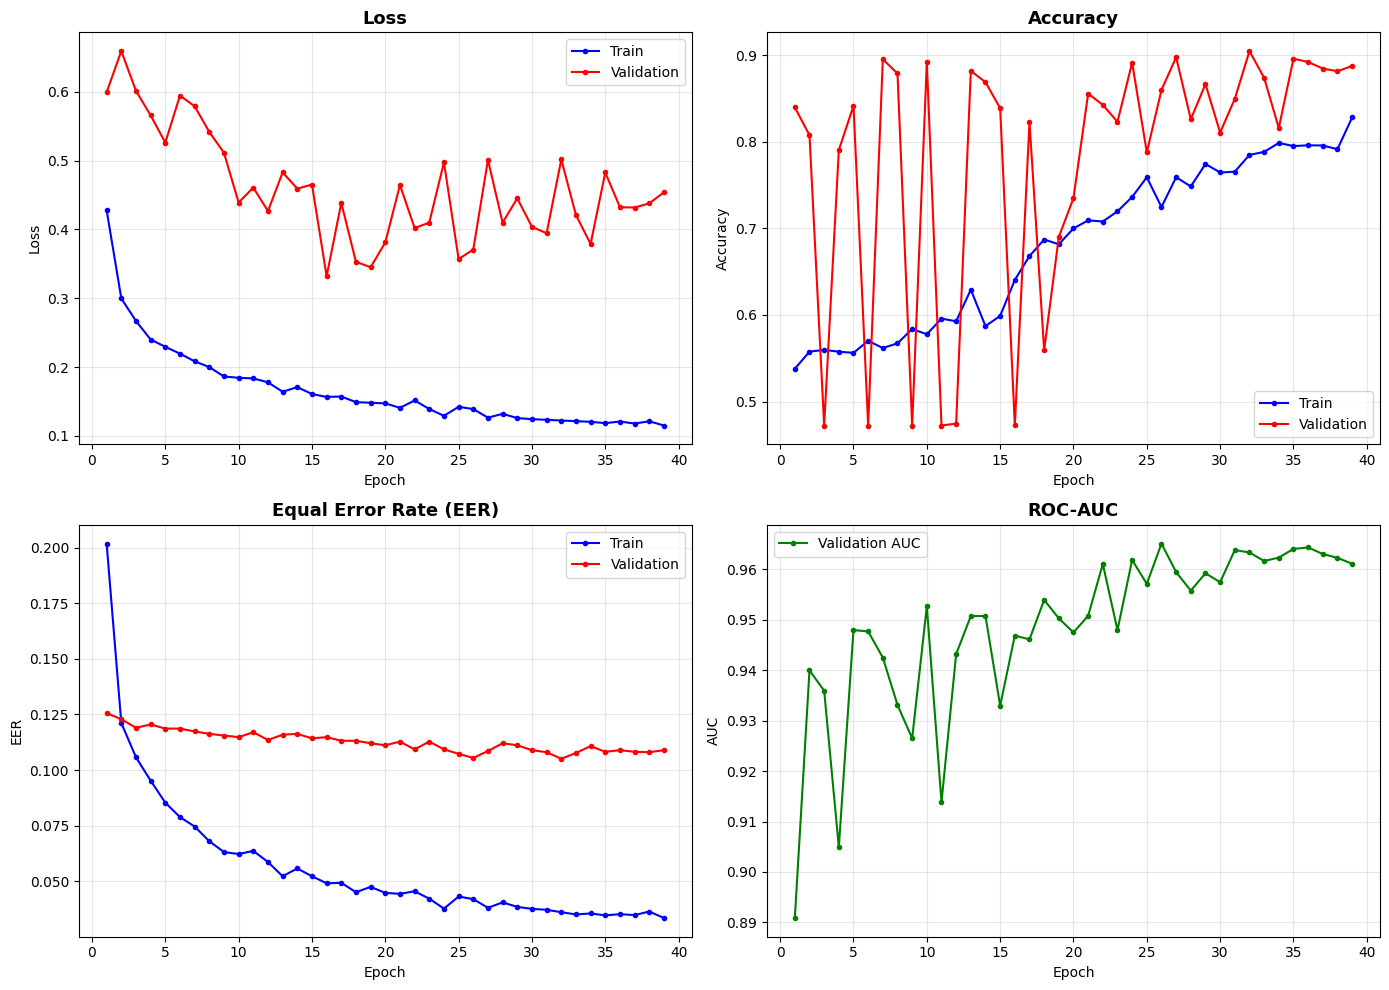

In [15]:
def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Loss
    axes[0, 0].plot(epochs, history['train_loss'], 'b-o', ms=3, label='Train')
    axes[0, 0].plot(epochs, history['val_loss'],   'r-o', ms=3, label='Validation')
    axes[0, 0].set_title('Loss', fontsize=13, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

    # Accuracy
    axes[0, 1].plot(epochs, history['train_acc'], 'b-o', ms=3, label='Train')
    axes[0, 1].plot(epochs, history['val_acc'],   'r-o', ms=3, label='Validation')
    axes[0, 1].set_title('Accuracy', fontsize=13, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

    # EER
    axes[1, 0].plot(epochs, history['train_eer'], 'b-o', ms=3, label='Train')
    axes[1, 0].plot(epochs, history['val_eer'],   'r-o', ms=3, label='Validation')
    axes[1, 0].set_title('Equal Error Rate (EER)', fontsize=13, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('EER')
    axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

    # AUC
    axes[1, 1].plot(epochs, history['val_auc'], 'g-o', ms=3, label='Validation AUC')
    axes[1, 1].set_title('ROC-AUC', fontsize=13, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('AUC')
    axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(history)

---
## Step 7 — Evaluation

Load the best model and evaluate on the held-out test set. Compute EER, ROC-AUC,
accuracy, precision, recall, F1. Plot confusion matrix, ROC curve, and DET curve.

In [16]:
ckpt = torch.load('best_model.pt', map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
eer_threshold = ckpt.get('eer_threshold', 0.0)
print(f"Loaded best model from epoch {ckpt['epoch']} (Val EER: {ckpt['val_eer']:.4f})")

test_results = evaluate(model, test_loader, DEVICE)

# Re-predict using the EER threshold from validation
test_preds_eer = (test_results['scores'] > eer_threshold).astype(int)
test_preds_eer = 1 - test_preds_eer  # above threshold = real (0)

print(f"\nTest Results:")
print(f"  Loss:     {test_results['loss']:.4f}")
print(f"  Accuracy: {test_results['acc']:.4f}")
print(f"  EER:      {test_results['eer']:.4f}")
print(f"  ROC-AUC:  {test_results['auc']:.4f}")

Loaded best model from epoch 32 (Val EER: 0.1051)


  Eval :   0%|          | 0/474 [00:00<?, ?it/s]


Test Results:
  Loss:     1.3755
  Accuracy: 0.8062
  EER:      0.1594
  ROC-AUC:  0.9364


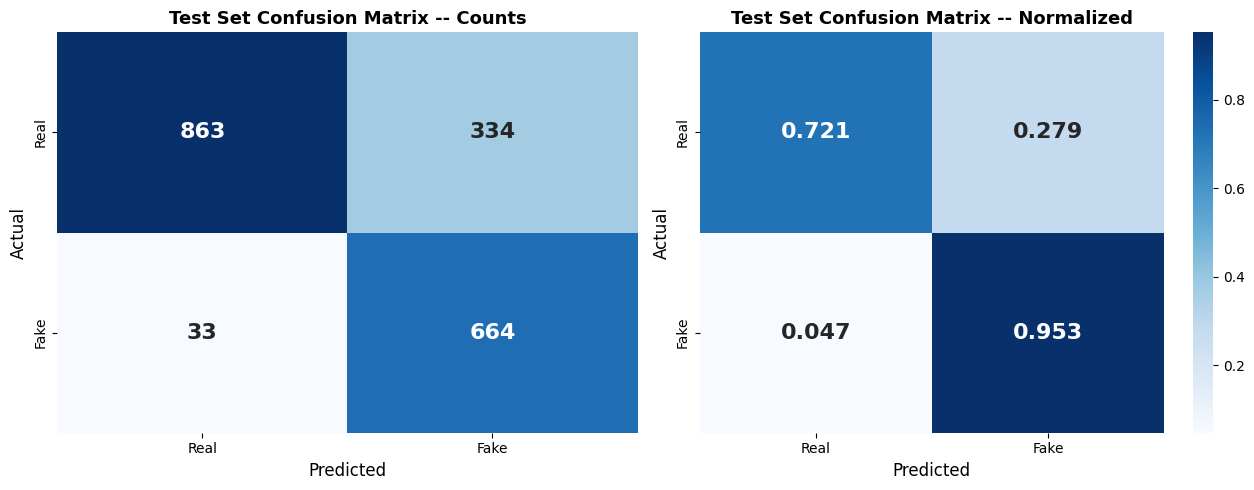

In [17]:
def plot_confusion_matrix(y_true, y_pred, labels=['Real', 'Fake'], title='Test Set Confusion Matrix'):
    cm = np.zeros((len(labels), len(labels)), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t][p] += 1

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels,
                yticklabels=labels, ax=axes[0], cbar=False,
                annot_kws={'size': 16, 'fontweight': 'bold'})
    axes[0].set_xlabel('Predicted', fontsize=12)
    axes[0].set_ylabel('Actual', fontsize=12)
    axes[0].set_title(f'{title} -- Counts', fontsize=13, fontweight='bold')

    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues', xticklabels=labels,
                yticklabels=labels, ax=axes[1], cbar=True,
                annot_kws={'size': 16, 'fontweight': 'bold'})
    axes[1].set_xlabel('Predicted', fontsize=12)
    axes[1].set_ylabel('Actual', fontsize=12)
    axes[1].set_title(f'{title} -- Normalized', fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    return cm

cm = plot_confusion_matrix(test_results['labels'], test_results['preds'])

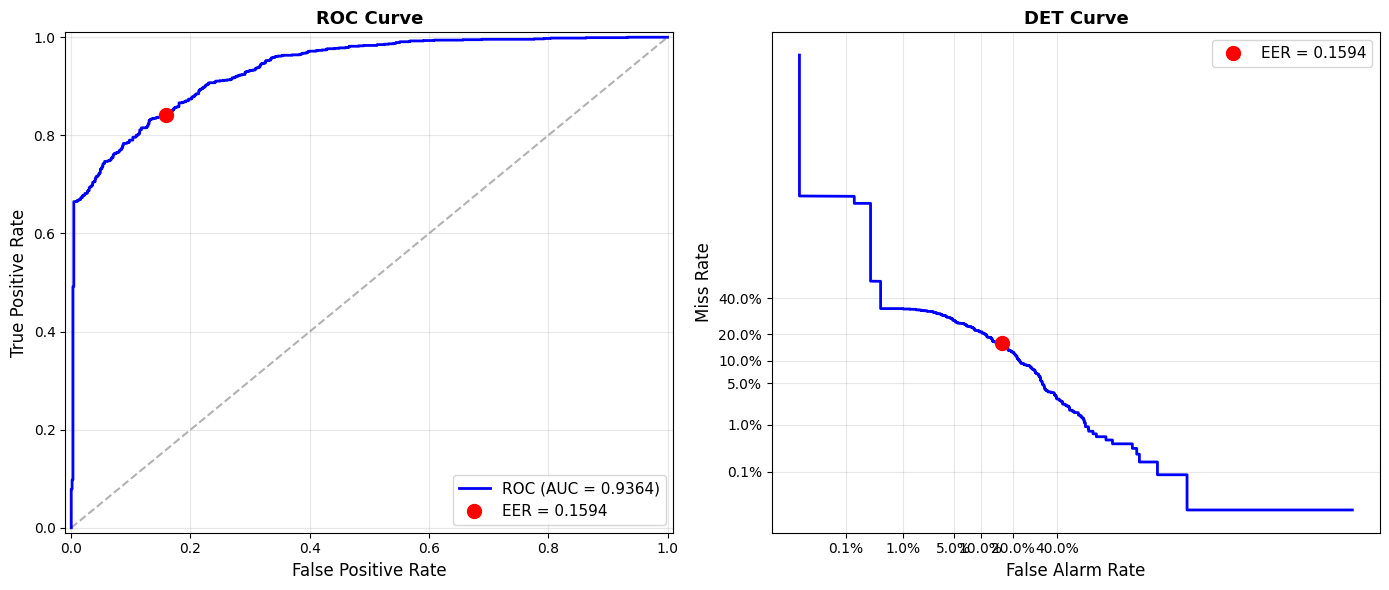

In [18]:
def plot_roc_det(fpr, tpr, eer, auc_val):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ROC
    axes[0].plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC = {auc_val:.4f})')
    axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
    axes[0].plot(eer, 1 - eer, 'ro', ms=10, label=f'EER = {eer:.4f}')
    axes[0].set_xlabel('False Positive Rate', fontsize=12)
    axes[0].set_ylabel('True Positive Rate', fontsize=12)
    axes[0].set_title('ROC Curve', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=11); axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim([-0.01, 1.01]); axes[0].set_ylim([-0.01, 1.01])

    # DET
    fnr = 1 - tpr
    fpr_c = np.clip(fpr, 1e-4, 1 - 1e-4)
    fnr_c = np.clip(fnr, 1e-4, 1 - 1e-4)
    fpr_p = scipy_norm.ppf(fpr_c)
    fnr_p = scipy_norm.ppf(fnr_c)

    axes[1].plot(fpr_p, fnr_p, 'b-', lw=2)
    eer_p = scipy_norm.ppf(np.clip(eer, 1e-4, 1 - 1e-4))
    axes[1].plot(eer_p, eer_p, 'ro', ms=10, label=f'EER = {eer:.4f}')

    ticks = [0.001, 0.01, 0.05, 0.1, 0.2, 0.4]
    tp = [scipy_norm.ppf(t) for t in ticks]
    tl = [f'{t*100:.1f}%' for t in ticks]
    axes[1].set_xticks(tp); axes[1].set_xticklabels(tl)
    axes[1].set_yticks(tp); axes[1].set_yticklabels(tl)
    axes[1].set_xlabel('False Alarm Rate', fontsize=12)
    axes[1].set_ylabel('Miss Rate', fontsize=12)
    axes[1].set_title('DET Curve', fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=11); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('roc_det_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_roc_det(test_results['fpr'], test_results['tpr'],
             test_results['eer'], test_results['auc'])

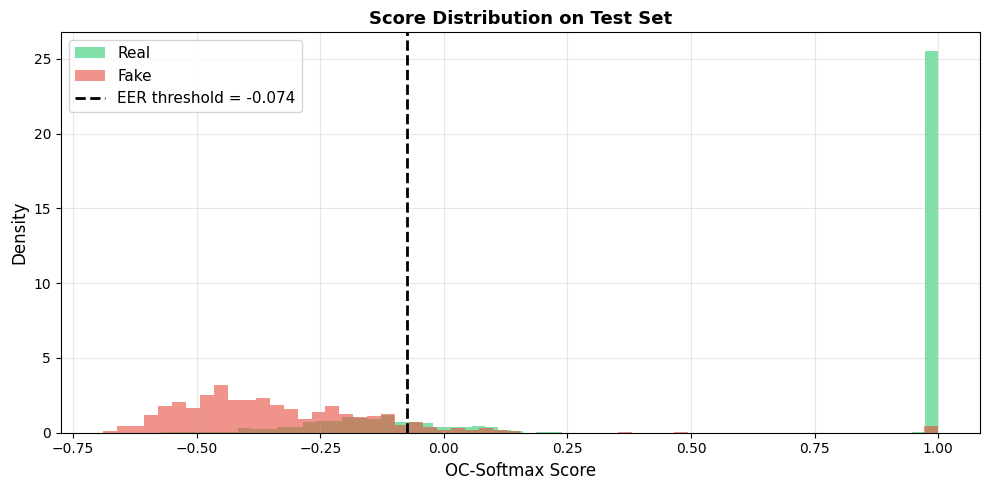


                  Precision     Recall         F1    Support
----------------------------------------------------------
Real                 0.9632     0.7210     0.8247       1197
Fake                 0.6653     0.9527     0.7835        697
----------------------------------------------------------
Accuracy                                   0.8062       1894
Weighted Avg         0.8536     0.8062     0.8095       1894


In [19]:
# Score distribution
fig, ax = plt.subplots(figsize=(10, 5))
real_scores = test_results['scores'][test_results['labels'] == 0]
fake_scores = test_results['scores'][test_results['labels'] == 1]
ax.hist(real_scores, bins=60, alpha=0.6, color='#2ecc71', label='Real', density=True)
ax.hist(fake_scores, bins=60, alpha=0.6, color='#e74c3c', label='Fake', density=True)
ax.axvline(x=eer_threshold, color='k', ls='--', lw=2, label=f'EER threshold = {eer_threshold:.3f}')
ax.set_xlabel('OC-Softmax Score', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Score Distribution on Test Set', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification report
def print_classification_report(y_true, y_pred, labels=['Real', 'Fake']):
    cm = np.zeros((len(labels), len(labels)), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t][p] += 1
    tp = np.diag(cm).astype(float)
    fp = cm.sum(axis=0).astype(float) - tp
    fn = cm.sum(axis=1).astype(float) - tp
    support = cm.sum(axis=1).astype(float)
    prec = np.divide(tp, tp + fp, out=np.zeros_like(tp), where=(tp + fp) > 0)
    rec  = np.divide(tp, tp + fn, out=np.zeros_like(tp), where=(tp + fn) > 0)
    f1   = np.divide(2 * prec * rec, prec + rec, out=np.zeros_like(tp), where=(prec + rec) > 0)
    acc  = tp.sum() / max(support.sum(), 1)
    w    = support / max(support.sum(), 1)

    print(f"\n{'':16s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s} {'Support':>10s}")
    print('-' * 58)
    for i, name in enumerate(labels):
        print(f"{name:16s} {prec[i]:10.4f} {rec[i]:10.4f} {f1[i]:10.4f} {int(support[i]):10d}")
    print('-' * 58)
    print(f"{'Accuracy':16s} {'':>10s} {'':>10s} {acc:10.4f} {int(support.sum()):10d}")
    print(f"{'Weighted Avg':16s} {(prec*w).sum():10.4f} {(rec*w).sum():10.4f} {(f1*w).sum():10.4f} {int(support.sum()):10d}")
    return {'accuracy': acc, 'precision': prec.tolist(), 'recall': rec.tolist(), 'f1': f1.tolist()}

report = print_classification_report(test_results['labels'], test_results['preds'])

---
## Step 8 — Robustness Testing

Evaluate the model under three types of degradation:
1. **Additive noise** at 10 dB SNR
2. **MP3 compression** simulation (4 kHz low-pass + quantization)
3. **Reverberation** (RT60 = 0.5s synthetic RIR)

Compare performance drop against the clean test set.

Clean            -- EER: 0.1594 | AUC: 0.9364 | Acc: 0.8062


  Eval :   0%|          | 0/474 [00:00<?, ?it/s]

10dB Noise       -- EER: 0.1837 | AUC: 0.9125 | Acc: 0.8105


  Eval :   0%|          | 0/474 [00:00<?, ?it/s]

MP3 Compress.    -- EER: 0.2223 | AUC: 0.8753 | Acc: 0.7782


  Eval :   0%|          | 0/474 [00:00<?, ?it/s]

Reverb (0.5s)    -- EER: 0.1806 | AUC: 0.9159 | Acc: 0.7856


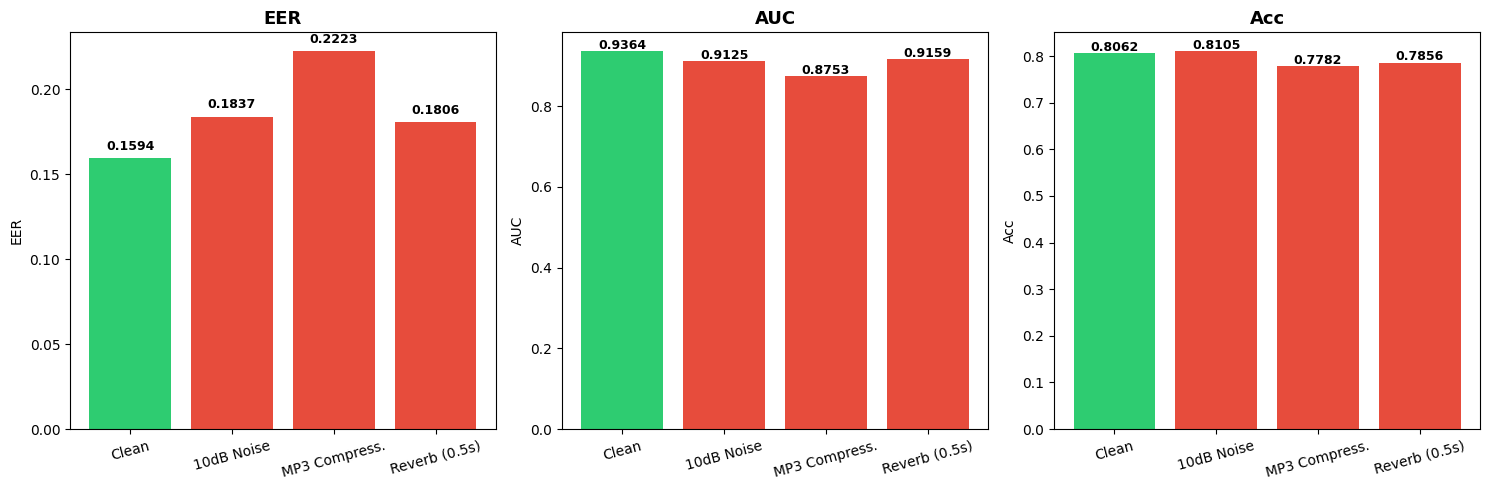

In [20]:
def apply_noise_10db(audio):
    sig_p = np.mean(audio ** 2) + 1e-10
    noise_p = sig_p / (10 ** (10 / 10))
    return audio + np.random.randn(len(audio)).astype(np.float32) * np.sqrt(noise_p)

def apply_mp3(audio):
    sos = butter(5, 4000 / (SAMPLE_RATE / 2), btype='low', output='sos')
    f = sosfilt(sos, audio).astype(np.float32)
    return np.round(f * 128).astype(np.float32) / 128

def apply_reverb(audio):
    n = int(SAMPLE_RATE * 0.5)
    t = np.arange(n, dtype=np.float32) / SAMPLE_RATE
    rir = np.random.randn(n).astype(np.float32) * np.exp(-6.9 * t / 0.5)
    rir[0] = 1.0; rir /= np.abs(rir).max() + 1e-8
    return fftconvolve(audio, rir, mode='full')[:len(audio)].astype(np.float32)

class CorruptedDataset(Dataset):
    def __init__(self, dataframe, corrupt_fn, sr=SAMPLE_RATE, duration=AUDIO_DURATION):
        self.df = dataframe.reset_index(drop=True)
        self.sr = sr
        self.max_len = sr * duration
        self.corrupt_fn = corrupt_fn

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        audio, _ = librosa.load(row['filepath'], sr=self.sr, duration=self.max_len / self.sr)
        if len(audio) < self.max_len:
            audio = np.pad(audio, (0, self.max_len - len(audio)))
        else:
            audio = audio[:self.max_len]
        audio = self.corrupt_fn(audio)
        audio = (audio - audio.mean()) / (audio.std() + 1e-7)
        return torch.from_numpy(audio.astype(np.float32)), torch.tensor(row['label'], dtype=torch.long)

corruptions = {
    'Clean':         None,
    '10dB Noise':    apply_noise_10db,
    'MP3 Compress.': apply_mp3,
    'Reverb (0.5s)': apply_reverb,
}

robustness_results = {}
for name, fn in corruptions.items():
    if fn is None:
        res = test_results
    else:
        ds = CorruptedDataset(test_df, fn)
        dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
        res = evaluate(model, dl, DEVICE)
    robustness_results[name] = {
        'EER': res['eer'], 'AUC': res['auc'], 'Acc': res['acc']
    }
    print(f"{name:16s} -- EER: {res['eer']:.4f} | AUC: {res['auc']:.4f} | Acc: {res['acc']:.4f}")

# Robustness comparison plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
names = list(robustness_results.keys())
for ax, metric in zip(axes, ['EER', 'AUC', 'Acc']):
    vals = [robustness_results[n][metric] for n in names]
    colors = ['#2ecc71'] + ['#e74c3c'] * (len(names) - 1)
    bars = ax.bar(names, vals, color=colors)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f'{b.get_height():.4f}', ha='center', fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('robustness_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 9 — Explainability

Visualize attention weights from the AASIST readout layer to understand which
temporal and spectral regions the model focuses on for classification.

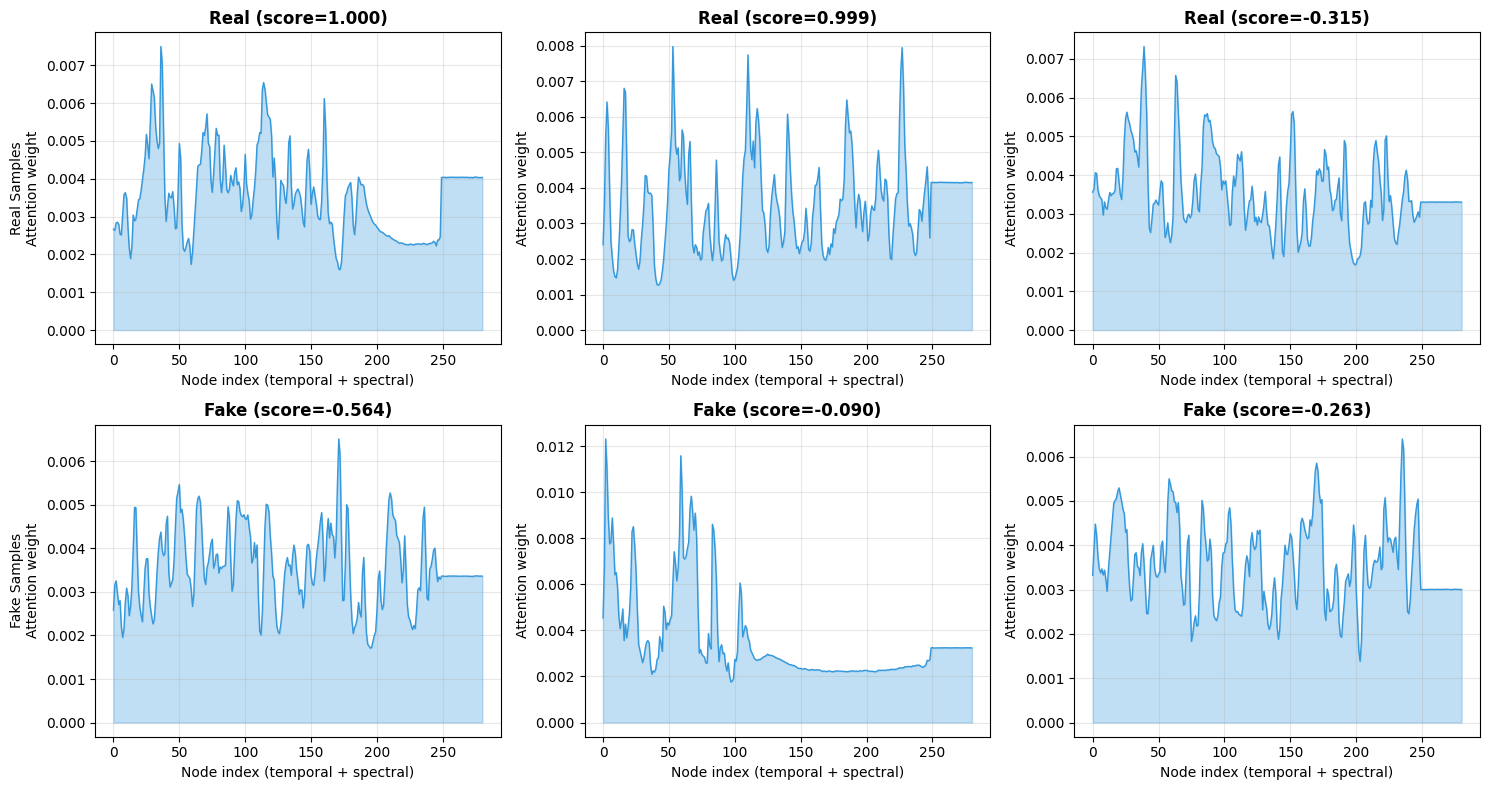

In [21]:
def visualize_attention(model, dataset, device, n_samples=3, seed=42):
    rng = np.random.default_rng(seed)
    model.eval()

    real_idx = [i for i in range(len(dataset)) if dataset.df.iloc[i]['label'] == 0]
    fake_idx = [i for i in range(len(dataset)) if dataset.df.iloc[i]['label'] == 1]
    chosen_real = rng.choice(real_idx, min(n_samples, len(real_idx)), replace=False)
    chosen_fake = rng.choice(fake_idx, min(n_samples, len(fake_idx)), replace=False)

    fig, axes = plt.subplots(2, n_samples, figsize=(5 * n_samples, 8))
    if n_samples == 1:
        axes = axes.reshape(2, 1)

    for col, (r_i, f_i) in enumerate(zip(chosen_real, chosen_fake)):
        for row, idx in enumerate([r_i, f_i]):
            audio, label = dataset[idx]
            audio_t = audio.unsqueeze(0).to(device)

            with torch.no_grad():
                with autocast(dtype=torch.float16, enabled=(device.type == 'cuda')):
                    scores, emb, attn = model(audio_t)

            # attn: [1, num_heads, 1, N] -> average over heads
            attn_np = attn.squeeze(0).squeeze(1).cpu().float().numpy()  # [heads, N]
            attn_avg = attn_np.mean(axis=0)  # [N]

            ax = axes[row, col]
            ax.plot(attn_avg, lw=1, color='#3498db')
            ax.fill_between(range(len(attn_avg)), attn_avg, alpha=0.3, color='#3498db')
            label_str = "Real" if label == 0 else "Fake"
            score_val = scores.item()
            ax.set_title(f'{label_str} (score={score_val:.3f})', fontweight='bold')
            ax.set_xlabel('Node index (temporal + spectral)')
            ax.set_ylabel('Attention weight')
            ax.grid(True, alpha=0.3)

    axes[0, 0].set_ylabel('Real Samples\nAttention weight')
    axes[1, 0].set_ylabel('Fake Samples\nAttention weight')
    plt.tight_layout()
    plt.savefig('attention_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_attention(model, test_ds, DEVICE, n_samples=3)

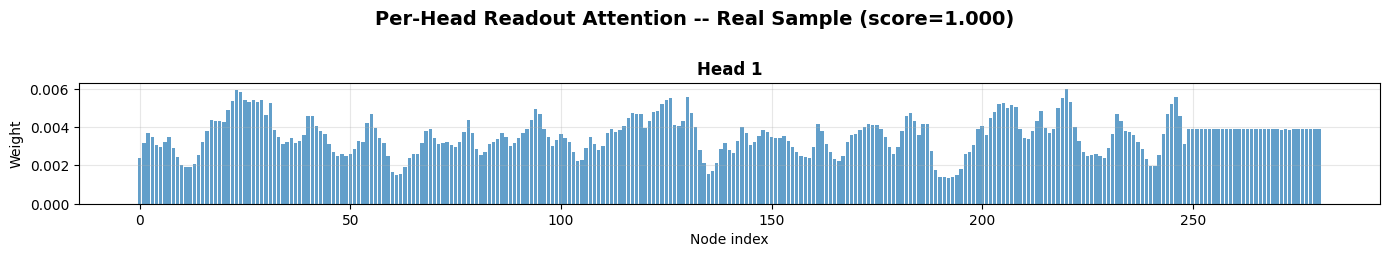

In [22]:
def visualize_attention_heads(model, dataset, device, sample_idx=0):
    model.eval()
    audio, label = dataset[sample_idx]
    audio_t = audio.unsqueeze(0).to(device)

    with torch.no_grad():
        with autocast(dtype=torch.float16, enabled=(device.type == 'cuda')):
            scores, emb, attn = model(audio_t)

    attn_np = attn.squeeze(0).squeeze(1).cpu().float().numpy()  # [heads, N]
    n_heads = attn_np.shape[0]
    label_str = "Real" if label == 0 else "Fake"

    fig, axes = plt.subplots(n_heads, 1, figsize=(14, 2.5 * n_heads))
    if n_heads == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        ax.bar(range(attn_np.shape[1]), attn_np[i], color=f'C{i}', alpha=0.7)
        ax.set_title(f'Head {i+1}', fontweight='bold')
        ax.set_ylabel('Weight')
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel('Node index')
    plt.suptitle(f'Per-Head Readout Attention -- {label_str} Sample (score={scores.item():.3f})',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('attention_heads.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_attention_heads(model, test_ds, DEVICE, sample_idx=0)

---
## Results Summary

Final metrics and model information.

In [23]:
results_summary = {
    'Architecture': 'WavLM-Large + Modified AASIST + OC-Softmax',
    'Dataset': f'{len(df)} samples ({(df["label"]==0).sum()} real, {(df["label"]==1).sum()} fake)',
    'Split': f'Train {len(train_df)} / Val {len(val_df)} / Test {len(test_df)} (speaker-independent)',
    'Best Epoch': ckpt['epoch'],
    'Test EER': f'{test_results["eer"]:.4f}',
    'Test ROC-AUC': f'{test_results["auc"]:.4f}',
    'Test Accuracy': f'{test_results["acc"]:.4f}',
    'Test Precision (Real)': f'{report["precision"][0]:.4f}',
    'Test Recall (Real)': f'{report["recall"][0]:.4f}',
    'Test F1 (Real)': f'{report["f1"][0]:.4f}',
    'Test Precision (Fake)': f'{report["precision"][1]:.4f}',
    'Test Recall (Fake)': f'{report["recall"][1]:.4f}',
    'Test F1 (Fake)': f'{report["f1"][1]:.4f}',
}

for cond, metrics in robustness_results.items():
    if cond != 'Clean':
        results_summary[f'Robustness {cond} EER'] = f'{metrics["EER"]:.4f}'

results_df = pd.DataFrame(list(results_summary.items()), columns=['Metric', 'Value'])
print(results_df.to_string(index=False))

results_df.to_csv('evaluation_results.csv', index=False)
print("\nResults saved to evaluation_results.csv")

                      Metric                                                    Value
                Architecture               WavLM-Large + Modified AASIST + OC-Softmax
                     Dataset                   26592 samples (13796 real, 12796 fake)
                       Split Train 19237 / Val 5461 / Test 1894 (speaker-independent)
                  Best Epoch                                                       32
                    Test EER                                                   0.1594
                Test ROC-AUC                                                   0.9364
               Test Accuracy                                                   0.8062
       Test Precision (Real)                                                   0.9632
          Test Recall (Real)                                                   0.7210
              Test F1 (Real)                                                   0.8247
       Test Precision (Fake)                          

In [24]:
save_info = {
    'model': 'BanglaDeepfakeDetector',
    'architecture': {
        'frontend': WAVLM_MODEL_NAME,
        'wavlm_freeze_layers': WAVLM_FREEZE_LAYERS,
        'backend': 'ModifiedAASIST',
        'hidden_dim': AASIST_HIDDEN,
        'emb_dim': AASIST_EMB_DIM,
        'num_heads': AASIST_NUM_HEADS,
        'num_gat_layers': AASIST_NUM_GAT_LAYERS,
        'num_spectral_nodes': NUM_SPECTRAL_NODES,
        'dropout': DROPOUT,
    },
    'loss': {'type': 'OCSoftmax', 'margin': OC_MARGIN, 'scale': OC_SCALE},
    'training': {
        'batch_size': BATCH_SIZE * ACCUMULATION_STEPS,
        'lr_wavlm': LR_WAVLM, 'lr_aasist': LR_AASIST,
        'weight_decay': WEIGHT_DECAY, 'grad_clip': GRAD_CLIP,
        'epochs_trained': ckpt['epoch'],
    },
    'test_metrics': {
        'eer': test_results['eer'], 'auc': test_results['auc'],
        'accuracy': test_results['acc'],
    },
    'robustness': robustness_results,
}

with open('model_info.json', 'w') as f:
    json.dump(save_info, f, indent=2)

print("Model info saved to model_info.json")
print("Best model checkpoint: best_model.pt")
print("\nPipeline complete.")

Model info saved to model_info.json
Best model checkpoint: best_model.pt

Pipeline complete.
